## 会员画像实战

In [93]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
%matplotlib inline

### 定义问题
运营部门想要依据销售订单数据，为用户分组画像


### RFM 

RFM是电商平台运营部门用来描述用户画像的特征数据，它们分别代表着
- R recency 代表用户上次消费以来天数
- F frequency 消费频率
- M money 消费金额


### 数据预处理
1. 先查看整体数据结构
2. 检查数据类型有无错误
3. 清洗数据:缺失/业务错误
4. 特征工程

In [2]:
df=pd.read_csv('dataset/order.csv')
df.head()

,订单号,产品码,消费日期,产品说明,数量,单价,用户码,城市
0,536374,21258,6/1/2020 9:09,五彩玫瑰五支装,32,10.95,15100,北京
1,536376,22114,6/1/2020 9:32,茉莉花白色25枝,48,3.45,15291,上海
2,536376,21733,6/1/2020 9:32,教师节向日葵3枝尤加利5枝,64,2.55,15291,上海
3,536378,22386,6/1/2020 9:37,百合粉色10花苞,10,1.95,14688,北京
4,536378,85099C,6/1/2020 9:37,橙黄香槟色康乃馨,10,1.95,14688,北京


In [3]:
df.describe()

,数量,单价,用户码
count,87180.000000,87180.000000,87180.000000
mean,10.006435,3.584552,15338.503774
std,48.769498,133.436042,392.001142
min,-9360.000000,0.000000,14681.000000
25%,2.000000,1.250000,15022.000000
50%,4.000000,1.950000,15335.000000
75%,12.000000,3.750000,15674.000000
max,3114.000000,38970.000000,16019.000000


In [ ]:
# 查看类型
print("转换前",df.dtypes)
df=df.convert_dtypes()
print("转换后",df.dtypes)

转换前 订单号             object
产品码             object
消费日期    datetime64[ns]
产品说明            object
数量               int64
单价             float64
用户码              int64
城市              object
dtype: object
转换后 订单号     string[python]
产品码     string[python]
消费日期    datetime64[ns]
产品说明    string[python]
数量               Int64
单价             Float64
用户码              Int64
城市      string[python]
dtype: object


In [ ]:
# 检查空值
df.loc[df.isna().any(axis=1)]

,订单号,产品码,消费日期,产品说明,数量,单价,用户码,城市


In [ ]:
# 类型转换
df.消费日期=pd.to_datetime(df.消费日期)
df.drop(df[df.数量<=0].index,inplace=True)
df.describe()

,消费日期,数量,单价,用户码
count,85354,85354.000000,85354.000000,85354.000000
mean,2021-01-05 02:50:01.557747968,10.641833,2.997970,15338.156712
min,2020-06-01 09:09:00,1.000000,0.000000,14681.000000
25%,2020-10-03 12:05:00,2.000000,1.250000,15021.000000
50%,2021-01-22 12:20:00,4.000000,1.950000,15334.000000
75%,2021-04-19 15:33:45,12.000000,3.750000,15674.000000
max,2021-06-09 12:31:00,3114.000000,3155.950000,16019.000000
std,NaN,33.788964,15.255909,392.798853


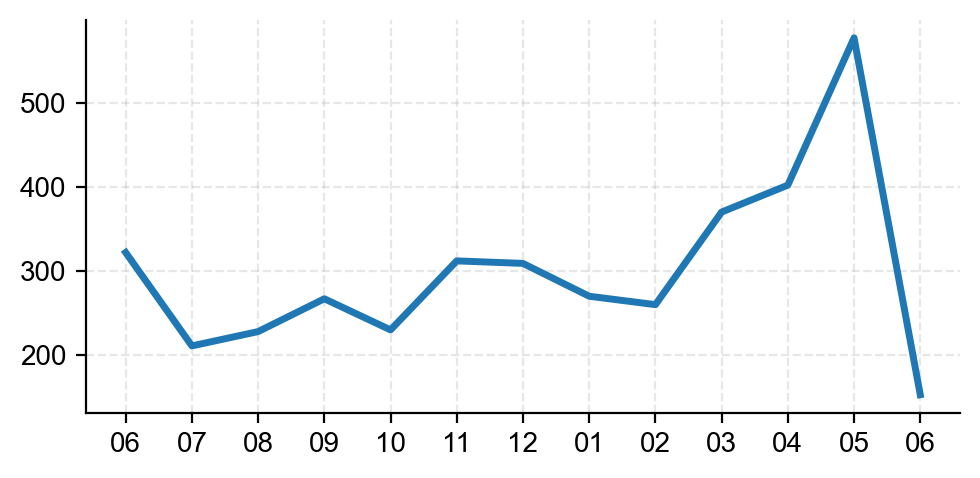

In [ ]:
# 查看月度销量
df_order=df.set_index('消费日期')['订单号'].resample('ME').nunique()
df_order.columns=['count']
df_order.index.rename('date',inplace=True)
x_vals = range(len(df_order))
plt.plot(x_vals, df_order.values)
ax=plt.gca()
ax.set_xticks(range(len(df_order)))
ax.set_xticklabels([x.strftime('%m')for x in df_order.index]);
plt.tight_layout()
plt.show()

In [191]:
# 提取 用户码
rfm=pd.DataFrame(df.用户码.unique())
rfm.columns=['用户码']
rfm.sort_values(by='用户码',ascending=True).reset_index(drop=True)
rfm


,用户码
0,15100
1,15291
2,14688
3,15311
4,15862
...,...
975,15318
976,16000
977,15195
978,15471


In [192]:
# 构造r
r=df.groupby('用户码').消费日期.max().reset_index()
r.columns=['用户码','最近日期']
# 最近日期-消费日期 （数据里最近)
r['R']=(r.最近日期.max()-r.最近日期).dt.days
r.drop(columns='最近日期',inplace=True)
r.head()

,用户码,R
0,14681,70
1,14682,187
2,14684,25
3,14687,106
4,14688,7


In [193]:
# 构造M
df['总价']=df.单价*df.数量
m=df.groupby('用户码').总价.sum().reset_index()
m.columns=['用户码','M']
m.head()

,用户码,M
0,14681,498.95
1,14682,52.0
2,14684,1236.28
3,14687,628.38
4,14688,5630.87


In [194]:
# 构造F
f=df.groupby('用户码').消费日期.count().reset_index()
f.columns=['用户码','F']
f.head()

,用户码,F
0,14681,7
1,14682,2
2,14684,421
3,14687,15
4,14688,327


In [195]:
# merge
rfm=pd.merge(rfm,r,on='用户码')
rfm=pd.merge(rfm,m,on='用户码')
rfm=pd.merge(rfm,f,on='用户码')
rfm

,用户码,R,M,F
0,15100,333,876.0,3
1,15291,25,4668.3,103
2,14688,7,5630.87,327
3,15311,0,60767.9,2379
4,15862,7,832.88,147
...,...,...,...,...
975,15318,3,312.62,33
976,16000,2,12393.7,9
977,15195,2,3861.0,1
978,15471,1,469.48,77


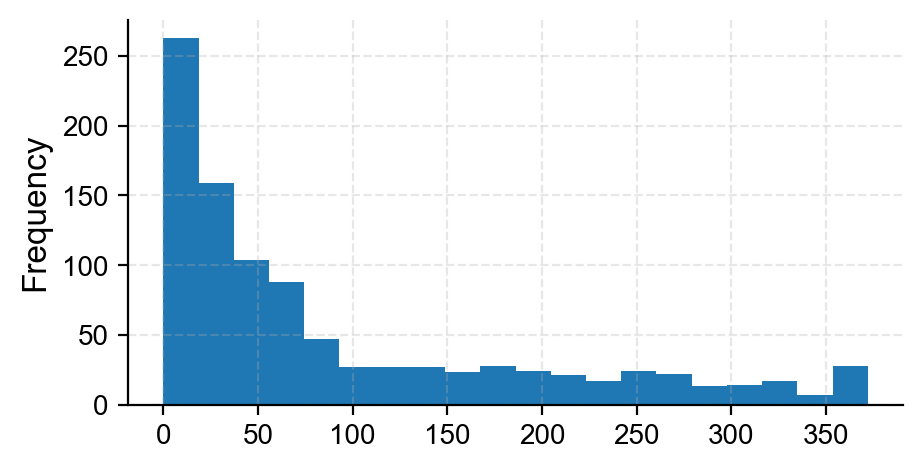

In [168]:
rfm['R'].plot(kind='hist', bins=20,); #R值直方图

<Axes: ylabel='Frequency'>

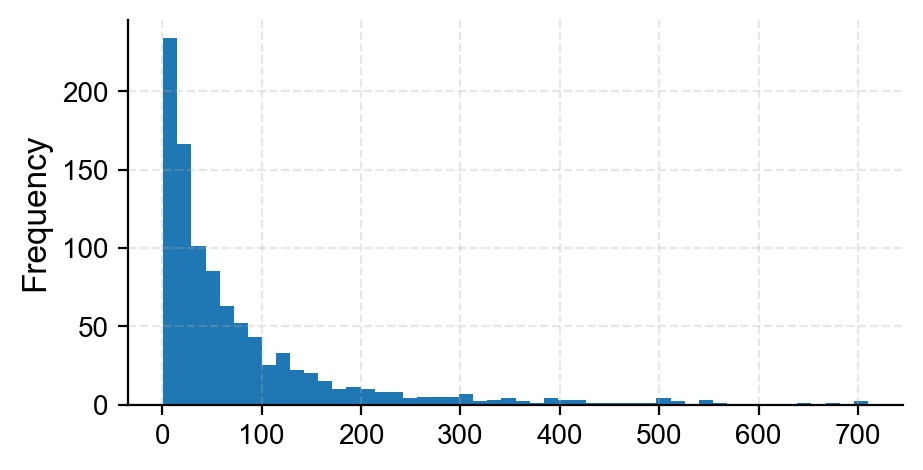

In [169]:
rfm.query('F < 800')['F'].plot(kind='hist', bins=50, ) #F值直方图

/var/folders/f7/rx7cmvdx6nl86z_s7s86w4zm0000gn/T/ipykernel_1660/3577795284.py:1: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  rfm.query('M < 20000')['M'].plot(kind='hist', bins=50,) #M值直方图


<Axes: ylabel='Frequency'>

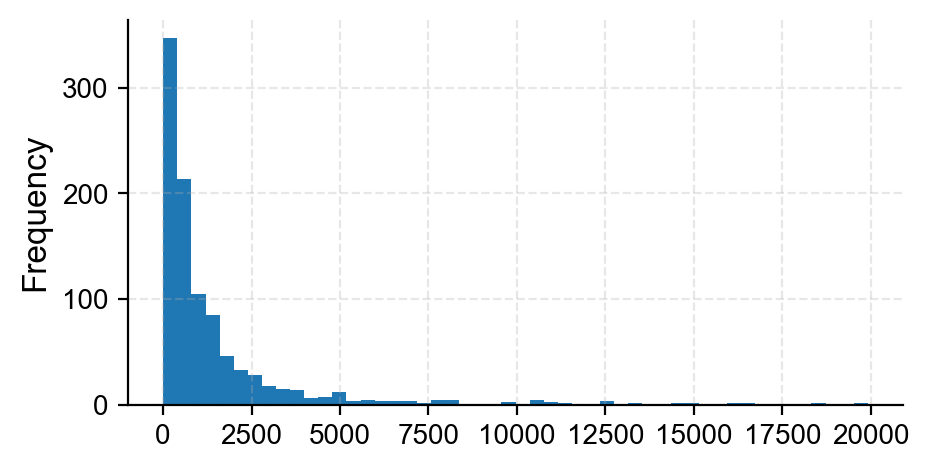

In [171]:
rfm.query('M < 20000')['M'].plot(kind='hist', bins=50,) #M值直方图

### k-means
通过k-means进行建模，对用户画像进行分组

通过观察损失函数的下降曲线来选取等级

$$
J(C^{(1)},C^{(2)},...,C^{(k)},u_1,...,u_k)=\frac{1}{m} \sum_{i=1}^m ||x^{(i)}-u_{ci}||^2
$$

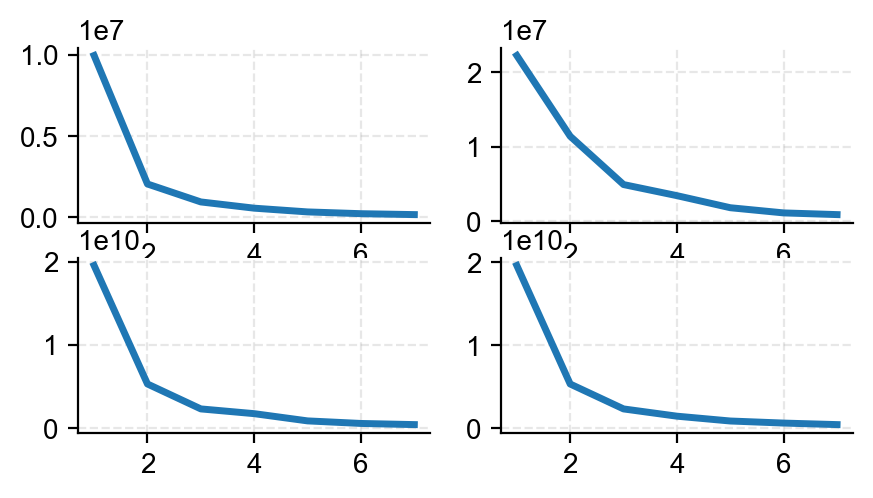

In [ ]:
# k-means 建模 选择
iter_num=range(1,8)
tol_r=[]
tol_f=[]
tol_m=[]
tol_=[]
for num in iter_num:
    km=KMeans(n_clusters=num,max_iter=100)
    model=km.fit(rfm.R.values.reshape(-1,1))
    tol_r.append(model.inertia_)

for num in iter_num:
    km=KMeans(n_clusters=num,max_iter=100)
    model=km.fit(rfm.F.values.reshape(-1,1))
    tol_f.append(model.inertia_)

for num in iter_num:
    km=KMeans(n_clusters=num,max_iter=100)
    model=km.fit(rfm.M.values.reshape(-1,1))
    tol_m.append(model.inertia_)



val=rfm.loc[:,['R','F','M']].values
for num in iter_num:
    km=KMeans(n_clusters=num,max_iter=100)
    model=km.fit(val)
    tol_.append(model.inertia_)

fig,ax=plt.subplots(ncols=2,nrows=2)
# 注意刻度
ax[0][0].plot(iter_num,tol_r)
ax[0][1].plot(iter_num,tol_f)
ax[1][0].plot(iter_num,tol_m)
ax[1][1].plot(iter_num,tol_)

In [202]:
# 组合数据

km_r=KMeans(n_clusters=3,max_iter=100)
m_r=km_r.fit(rfm.R.values.reshape(-1,1))
rfm['R-level']=m_r.predict(rfm.R.values.reshape(-1,1))

km_f=KMeans(n_clusters=4,max_iter=100)
m_f=km_f.fit(rfm.F.values.reshape(-1,1))
rfm['F-level']=m_f.predict(rfm.F.values.reshape(-1,1))

km_m=KMeans(n_clusters=3,max_iter=100)
m_m=km.fit(rfm.M.values.reshape(-1,1))
rfm['M-level']=m_m.predict(rfm.M.values.reshape(-1,1))


rfm['总分']=rfm['R-level']+rfm['F-level']+rfm['M-level']

rfm.sort_values(by='总分')


,用户码,R,M,F,R-level,F-level,M-level,总分
54,15708,40,3364.24,288,0,0,0,0
349,15974,38,3442.15,176,0,0,0,0
368,15416,64,3984.32,192,0,0,0,0
403,15632,15,3285.31,167,0,0,0,0
456,15249,31,6688.46,350,0,0,0,0
...,...,...,...,...,...,...,...,...
140,15596,100,1406.59,77,2,2,6,10
519,15265,150,1506.12,82,2,2,6,10
685,15372,136,2007.4,27,2,2,6,10
361,14740,196,1448.21,89,2,2,6,10
